# **FINAL PROJECT KELOMPOK GAMMA**

by Ayudhia Surya Taufiqa Rahma, Muhammad Haikal Athallah, Quaishum Syantini

### ***Telco Customer Churn Analysis***

**GAMBARAN UMUM**

Perusahaan Telekomunikasi (Telco) adalah perusahaan yang menyediakan layanan digital berupa internet, telefon, dan streaming TV. Saat ini, jaringan Telco telah menjangkau seluruh wilayah Indonesia dan Telco terus berinovasi untuk memenuhi kebutuhan masyarakat akan layanan internet yang lebih baik.

**LATAR BELAKANG**

Industri telekomunikasi menjadi salah satu sektor yang berkembang sangat cepat pada era digital saat ini yang didorong oleh peningkatan penggunaan ponsel dan internet, yang menyebabkan tantangan seperti pelanggan yang berhenti berlangganan. Dimana perusahaan telekomunikasi (Telco) memiliki peran untuk memberikan layanan Internet kepada masyarakat dan dengan harapan untuk meningkatkan keuntungan bisnis di bidang layanan jaringan internet. ***Tingginya tingkat kepindahan pelanggan (customer churn)*** menjadi ancaman serius bagi stabilitas pendapatan perusahaan telekomunikasi, mengingat biaya akuisisi pelanggan baru jauh lebih mahal daripada mempertahankan pelanggan lama. Churn menandakan ***ketidakpuasan pelanggan*** dan mempengaruhi stabilitas keuangan, reputasi, dan efisiensi operasional. ***Menganalisis faktor yang berkaitan dengan churn dan mengurangi churn*** sangat penting untuk mempertahankan daya saing dan keberlanjutan di sektor ini.

**RUMUSAN MASALAH**

1. **Faktor Risiko Utama** : Faktor-faktor apa saja (seperti jenis kontrak, layanan internet, dan masa langganan/tenure) yang paling dominan memengaruhi keputusan pelanggan untuk melakukan churn?

2. **Korelasi Layanan & Segmentasi** : Bagaimana hubungan antara pemilihan jenis layanan (Internet Service, dll.) terhadap keputusan churn dalam menentukan target market dan segmen pelanggan yang tepat?

3. **Pengaruh Kontrak & Dampak Pendapatan** : Bagaimana pengaruh jenis kontrak dan tenure terhadap churn rate, serta berapa potensi kerugian pendapatan (potential revenue loss) yang timbul dari tingginya churn pada jenis kontrak tertentu?

4. **Rekomendasi Strategi Retensi** : Strategi retensi bisnis seperti apa yang paling cocok direkomendasikan untuk menekan risiko churn dan meningkatkan loyalitas pelanggan?

**TUJUAN**

1. **Mengidentifikasi Faktor Utama Churn** : Mengidentifikasi dan menganalisis variabel kunci (*Contract, Internet Service, dan Tenure*) yang secara signifikan menjadi pemicu utama churn pelanggan pada layanan telco

2. **Memetakan Target Market & Segmen Berisiko** : Menganalisis korelasi jenis layanan dengan tingkat churn untuk memetakan segmen pelanggan berisiko tinggi (*high-risk segment*) serta menentukan target market yang lebih proporsional

3. **Mengevaluasi Risiko Kontrak & Dampak Revenue** : Mengevaluasi dampak pilihan jenis kontrak dan tenure terhadap keberlangsungan langganan, serta mengestimasi potensi kerugian pendapatan (*revenue loss*) akibat tingginya churn pada kontrak jangka pendek

4. **Merumuskan Strategi Retensi Bisnis** : Merumuskan rekomendasi strategi retensi pelanggan yang tepat sasaran (berbasis hasil analisis faktor dan segmen) guna menekan tingkat churn dan mengoptimalkan retensi pelanggan secara berkelanjutan.

**STAKEHOLDER FOCUS**

Dalam focus problem yang terjadi di layanan telco ini, ditujukan untuk tim **SALES** dimana berkaitan dengan pendapatan, jenis kontrak, dan penawaran produk yang tersedia dilayanan telco ini agar menekan resiko churn yang terjadi sehingga mendapatkan customer yang loyal serta memberikan experience yang baik

---


IMPORT DATA

In [ ]:
import pandas as pd
import numpy as np
df_telco = pd.read_csv('Telco_Customer_Churn.csv')

# 1. DATA UNDERSTANDING #

**1.1 SUMBER DATA**

- Sumber: Telco Customer Churn (IBM Sample Dataset)
- Ukuran: 7.043 baris x 21 kolom
- Unit analisis: 1 baris = 1 pelanggan ( customerID unik untuk tiap baris)
- Periode: snapshot satu waktu (tidak ada kolom tanggal/waktu historis)



**1.2 DATASET DICTIONARY**

**Tabel telco.csv**
| Nama Kolom | Deskripsi |
| :--- | :--- |
| customerID | ID unik pengguna layanan telco |
|gender | Jenis kelamin pelanggan (Female atau Male)|
|SeniorCitizen | Status warga senior/lansia (0 = Bukan, 1 = Ya)|
|Partner |Apakah pelanggan memiliki pasangan (Yes atau No)|
| Dependends | Apakah pelanggan memiliki tanggungan keluarga (Yes atau No)|
| tenure | Jumlah bulan pelanggan telah menggunakan layanan perusahaan|
| PhoneService | Apakah pelanggan berlangganan layanan telepon (Yes atau No)|
| MultipleLines | Apakah pelanggan memiliki banyak saluran telepon (Yes, No, atau No phone service)|
| InternetService | Jenis layanan internet yang digunakan (DSL, Fiber optic, atau No) |
| OnlineSecurity | Apakah pelanggan berlangganan fitur keamanan online (Yes, No, atau No internet service) |
| OnlineBackup | Apakah pelanggan berlangganan fitur backup online (Yes, No, atau No internet service)|
| DeviceProtection | Apakah pelanggan memiliki perlindungan perangkat (Yes, No, atau No internet service) |
| TechSupport | Apakah pelanggan berlangganan dukungan teknis (Yes, No, atau No internet service) |
| StreamingTV | Apakah pelanggan berlangganan layanan streaming TV (Yes, No, atau No internet service) |
| StreamingMovies | Apakah pelanggan berlangganan layanan streaming film (Yes, No, atau No internet service) |
| Contract | Jangka waktu kontrak langganan (Month-to-month, One year, atau Two year) |
| PaperlessBilling | Apakah pelanggan menggunakan tagihan digital/tanpa kertas (Yes atau No) |
| PaymentMethod | Metode pembayaran yang digunakan pelanggan (contoh: Electronic check, Mailed check, Bank transfer, dll). |
| MonthlyCharges | Jumlah biaya yang ditagihkan ke pelanggan setiap bulannya |
| TotalCharges | Akumulasi total biaya yang telah dibebankan kepada pelanggan selama berlangganan |
| Churn | Status apakah pelanggan berhenti berlangganan atau keluar (Yes atau No) |





**1.3 Kenapa Churn adalah Target, bukan fitur**

Dalam kerangka "Data (Specific for Machine Learning)" yang mungkin familiar dari materi kelas — meski project ini tidak
memakai ML, prinsip yang sama tetap berlaku secara konseptual: Churn adalah hal yang ingin kita pahami/jelaskan
(outcome), sedangkan 20 kolom lainnya adalah kemungkinan faktor yang menjelaskannya (predictor). Semua analisis di
Bagian 6-8 pada dasarnya menjawab: "kombinasi nilai fitur seperti apa yang paling banyak berujung pada Churn=Yes?"

In [ ]:
df_telco.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
display(df_telco.head(10), df_telco.tail(10))


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---

# 2. DATA CLEANING #

Cleaning data berdasarkan temuan di tahap Data Understanding:
1. Konversi `TotalCharges` ke tipe numerik
2. Isi 11 baris kosong di kolom `TotalCharges` dengan 0 (bukan dihapus): pelanggan baru belum ditagih ->  knp pelanggan baru - Karena dari 11 baris tersebut `Tenure` = 0
3. Ubah `SeniorCitizen` dari format 0/1 menjadi 'No'/'Yes' agar konsisten dengan kolom kategorikal lain
4. Terdapat missing value
5. Tidak memiiki duplicate data
6. Verifikasi ulang hasil cleaning

**Formating Dtype**

Mengubah tipe data totalcharges dari string ke float karena numeric

In [ ]:
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')

df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Check Duplicate data**

Setelah kami analisis terkait duplicate data bahwa tidak ada indikasi duplicate data pada dataset telco ini

In [ ]:
print("Telco - full row duplicate:", df_telco.duplicated().sum())

Telco - full row duplicate: 0


In [ ]:
df_telco.duplicated().sum()

np.int64(0)

***Insight*** : Hasil menunjukkan terdapat 0 duplicate data, sehingga tidak diperlukan penghapusan data duplikat pada dataset

**Check Missing Value**

In [ ]:
description = pd.DataFrame({
    "Type" : df_telco.dtypes,
    "Missing_Value" : df_telco.isna().sum(),
    "Unique_value" : df_telco.nunique(),
    "Unique_Data" : df_telco.apply(lambda x: x.unique())
})
description

,Type,Missing_Value,Unique_value,Unique_Data
customerID,object,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,object,0,2,"[Female, Male]"
SeniorCitizen,int64,0,2,"[0, 1]"
Partner,object,0,2,"[Yes, No]"
Dependents,object,0,2,"[No, Yes]"
tenure,int64,0,73,"[1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ..."
PhoneService,object,0,2,"[No, Yes]"
MultipleLines,object,0,3,"[No phone service, No, Yes]"
InternetService,object,0,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,0,3,"[No, Yes, No internet service]"


Terlihat pada dataset telco ini terdapat missing value

Hasil pemeriksaan struktur dan kualitas dataset menunjukkan bahwa dari total 7.043 baris data, sebagian besar kolom bertipe data teks (string) dengan rata-rata seluruh kolom bersih dari nilai kosong (bernilai 0), kecuali pada kolom TotalCharges yang memiliki 11 missing value (yang umumnya berasal dari pelanggan baru dengan tenure 0 bulan). Selain itu, kolom target Churn memiliki dua kategori unik yaitu Yes dan No, sedangkan kolom fitur kategorikal lainnya seperti Contract, InternetService, dan PaymentMethod menampilkan variasi opsi layanan lengkap yang digunakan oleh pelanggan.



---



Pada bagian selanjutnya menampilkan data lanjutan untuk data cleaning dengan adanya mengisi string yang kosong menjadi Nan, isi Nan dengan 0, dan standarisasi seniorcitizen dari data menggunakan numeric menjadi Yes/No untuk menyamakan konsistensi tipe data dengan kolom **partner dan dependents**

In [ ]:
df_clean = df_telco.copy()

# Konversi TotalCharges ke numerik. String kosong otomatis berubah jadi NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Mengisi NaN dengan 0 -> karena 11 baris ini valid: pelanggan baru dengan tenure 0
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# Standarisasi SeniorCitizen: 0/1 -> No/Yes
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

df_clean.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


*Setelah proses cleaning, data menjadi lebih konsisten dan siap digunakan untuk tahap Exploratory Data Analysis (EDA)*

In [ ]:
# Verifikasi hasil cleaning
print("Tipe data TotalCharges sekarang:", df_clean['TotalCharges'].dtype)
print("Sisa missing value:", df_clean.isnull().sum().sum())
print("Contoh isi SeniorCitizen:", df_clean['SeniorCitizen'].unique())

Tipe data TotalCharges sekarang: float64
Sisa missing value: 0
Contoh isi SeniorCitizen: ['No' 'Yes']


***Insight*** : Hasil verifikasi menunjukkan TotalCharges sudah bertipe numerik, tidak terdapat missing value, dan SeniorCitizen telah distandarisasi menjadi kategori Yes dan No

**Check Data Outlier**

Berdasarkan analisis bahwa tidak menunjukkan adanya data outlier

In [ ]:
# Hitung Q1 dan Q3 HANYA pada kolom numerik
Q1 = df_telco.select_dtypes(include=['number']).quantile(0.25)
Q3 = df_telco.select_dtypes(include=['number']).quantile(0.75)

# Hitung IQR
IQR = Q3 - Q1

print("Nilai IQR untuk tiap kolom numerik:")
print(IQR)

Nilai IQR untuk tiap kolom numerik:
SeniorCitizen        0.0000
tenure              46.0000
MonthlyCharges      54.3500
TotalCharges      3393.2875
dtype: float64


# 3. EDA

### A. Churn Rate Analysis


Menampilkan perbandingan churn rate dimana dari total 7rb data pelanggan terdapat churn 26,5% dan retained 73.5%

In [ ]:
# Proporsi Churn keseluruhan (baseline)
churn_rate = df_clean['Churn'].value_counts(normalize=True) * 100
print(churn_rate.round(1))


Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


***Insight*** : Dari 7.043 pelanggan, sebesar 73,5% masih bertahan, sedangkan 26,5% melakukan churn. Angka ini menjadi baseline untuk membandingkan risiko churn pada kelompok pelanggan lainnya

----------

## Visualisasi Pie Chart & Bar Chart untuk Proporsi Churn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_464/2054339751.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_telco, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax[1])


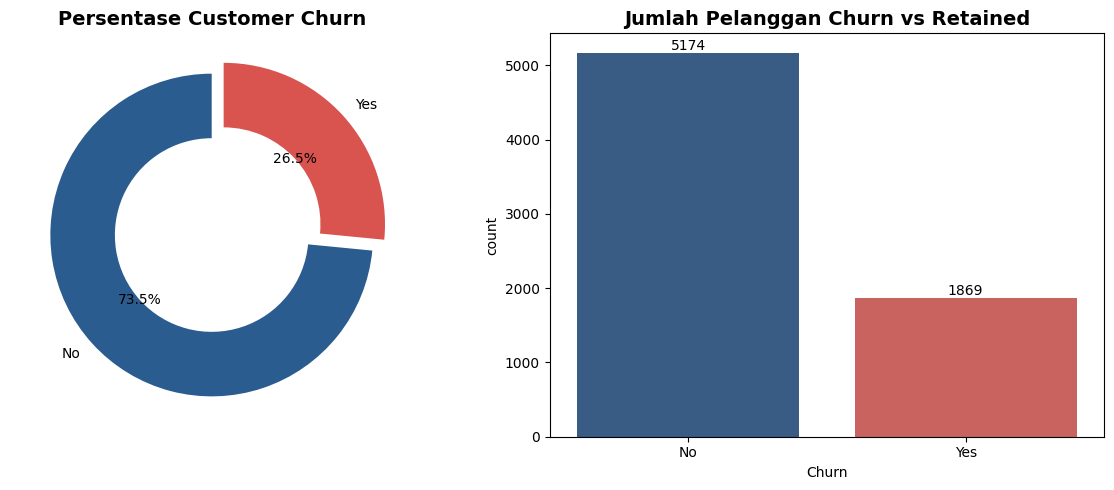

In [ ]:
churn_counts = df_telco['Churn'].value_counts()
churn_pct = df_telco['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
          startangle=90, colors=['#2b5c8f', '#d9534f'], explode=(0, 0.1), wedgeprops=dict(width=0.4))
ax[0].set_title('Persentase Customer Churn', fontsize=14, fontweight='bold')

# Count Plot

sns.countplot(data=df_telco, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax[1])
ax[1].set_title('Jumlah Pelanggan Churn vs Retained', fontsize=14, fontweight='bold')
for p in ax[1].patches:
    ax[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

***Insight*** : Mayoritas pelanggan masih bertahan sebesar `73,5%`, tetapi terdapat `26,5%` pelanggan yang churn. Yang mana secara nilai atau data pelanggannya yang bertahan sejumlah `5.174` sedangkan yang churn sejumlah `1.869`. Sehingga churn menjadi masalah yang perlu dianalisis lebih lanjut untuk mengetahui faktor yang berkaitan dengan keputusan pelanggan berhenti berlangganan

----------

**Check Early Life Churn Pada Bulan pertama**

In [ ]:
early_churn = df_telco[df_telco['tenure'] == 1]['Churn'].value_counts(normalize=True)
print(early_churn)

Churn
Yes    0.619902
No     0.380098
Name: proportion, dtype: float64


/tmp/ipykernel_464/1761913680.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cohort_data, x='Cohort_Tenure', y='Churn_Rate', palette='Reds_r')


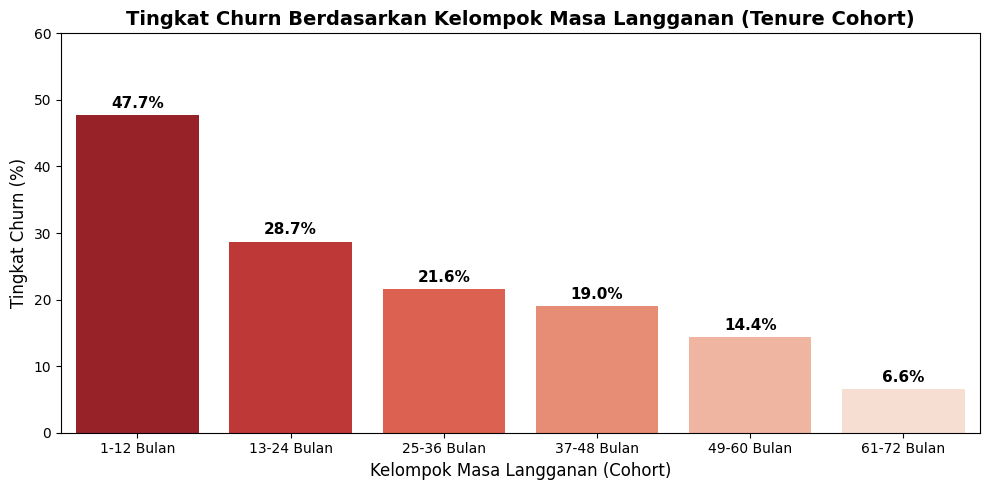

In [ ]:
# 1. Buat kelompok Cohort berdasarkan Tenure (Masa Langganan dalam Bulan)
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['1-12 Bulan', '13-24 Bulan', '25-36 Bulan', '37-48 Bulan', '49-60 Bulan', '61-72 Bulan']
df_telco['Tenure_Cohort'] = pd.cut(df_telco['tenure'], bins=bins, labels=labels)

# 2. Hitung persentase churn per kelompok cohort
cohort_data = df_telco.groupby('Tenure_Cohort', observed=False)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
cohort_data.columns = ['Cohort_Tenure', 'Churn_Rate']

# 3. Plotting menggunakan Seaborn
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cohort_data, x='Cohort_Tenure', y='Churn_Rate', palette='Reds_r')
plt.title('Tingkat Churn Berdasarkan Kelompok Masa Langganan (Tenure Cohort)', fontsize=14, fontweight='bold')
plt.xlabel('Kelompok Masa Langganan (Cohort)', fontsize=12)
plt.ylabel('Tingkat Churn (%)', fontsize=12)
plt.ylim(0, 60)

# Tambahkan label teks di atas batang grafik
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig('tenure_cohort_churn.png', dpi=300)
plt.show()

Berdasarkan analisis cohort pada grafik di atas, tingkat churn tertinggi terkonsentrasi pada kelompok masa langganan 1–12 bulan pertama (mencapai 47.7%) yang berartikan bahwa di tahun pertama langganan cukup tinggi resiko churn yang terjadi dan seiring masa tenure yang semakin lama semakin kecil persentase churn nya, termasuk juga penurunan yang stabil tidak ada lonjakan yang signifikan

***Insigtht*** :

Titik Kritis Berada di Tahun Pertama (1-12 Bulan):

Tingkat churn melonjak sangat tinggi di kelompok masa langganan 1–12 bulan, yaitu mencapai 47.7%.

Artinya, hampir separuh pelanggan baru berisiko tinggi meninggalkan layanan di tahun pertama mereka bergabung.

Ini adalah zona merah utama yang harus dijaga ketat oleh tim Sale

**Sample Data Buat Cohort Analysis Detail**

Ambil di 12 bulan pertama pada 2025

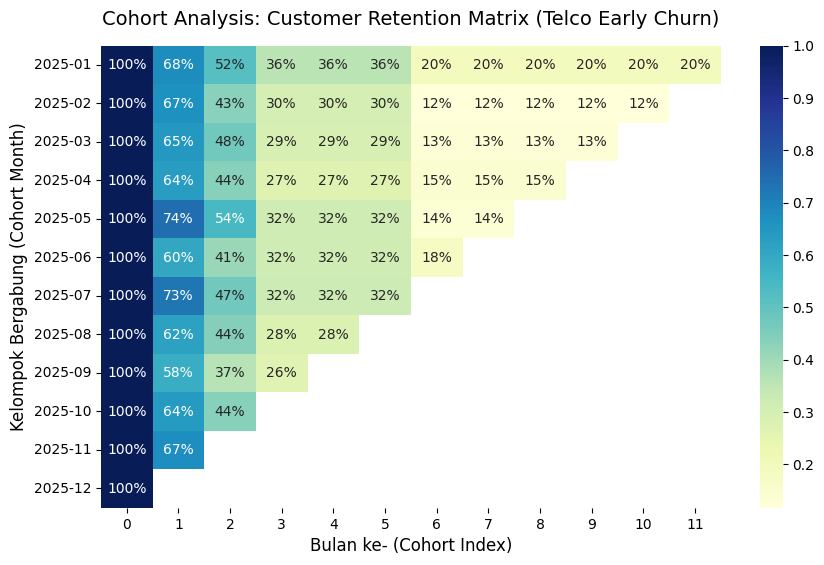

In [ ]:
# 1. Membuat Simulasi Data Transaksi/Langganan Telco
np.random.seed(42)
n_users = 2000

# Simulasi tanggal bergabung (Signup Date) sepanjang tahun 2025
start_date = pd.to_datetime('2025-01-01')
end_date = pd.to_datetime('2025-12-31')
signup_dates = start_date + pd.to_timedelta(np.random.randint(0, 365, n_users), unit='D')
customer_ids = [f'Cust_{i}' for i in range(n_users)]

df_sim = pd.DataFrame({'CustomerID': customer_ids, 'SignupDate': signup_dates})
df_sim['CohortMonth'] = df_sim['SignupDate'].dt.to_period('M')

# Simulasi aktivitas bulanan pelanggan (berapa bulan mereka bertahan)
# Merepresentasikan early churn yang tinggi di bulan-bulan awal
activity_records = []
for idx, row in df_sim.iterrows():
    c_id = row['CustomerID']
    c_month = row['CohortMonth']

    # Menentukan berapa lama pelanggan bertahan (cenderung drop di bulan 1-3)
    lifespan = np.random.choice([1, 2, 3, 6, 12], p=[0.35, 0.20, 0.15, 0.15, 0.15])

    for i in range(lifespan):
        active_month = c_month + i
        if active_month <= pd.Period('2025-12', freq='M'):
            activity_records.append({'CustomerID': c_id, 'CohortMonth': c_month, 'OrderMonth': active_month})

df_activity = pd.DataFrame(activity_records)

# 2. Menghitung Selisih Bulan (Cohort Index)
df_activity['CohortIndex'] = (df_activity['OrderMonth'] - df_activity['CohortMonth']).apply(lambda x: x.n)

# 3. Membuat Tabel Pivot (Matriks Kotak) untuk Jumlah Pelanggan
cohort_counts = df_activity.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerID', aggfunc='nunique')

# 4. Mengubah Menjadi Persentase Retention Rate
cohort_sizes = cohort_counts.iloc[:, 0]
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)

# 5. Visualisasi Matriks Kotak (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu', cbar=True)
plt.title('Cohort Analysis: Customer Retention Matrix (Telco Early Churn)', fontsize=14, pad=15)
plt.xlabel('Bulan ke- (Cohort Index)', fontsize=12)
plt.ylabel('Kelompok Bergabung (Cohort Month)', fontsize=12)
plt.show()

Heatmap digunakan untuk memvisualisasikan perubahan retention rate setiap kelompok pelanggan dari waktu ke waktu. Setiap baris menunjukkan cohort berdasarkan bulan ketika pelanggan bergabung, sedangkan setiap kolom menunjukkan bulan keberapa sejak pelanggan tersebut bergabung. Warna dan persentase menunjukkan proporsi pelanggan yang masih bertahan pada setiap periode

***Insight*** : Berdasarkan cohort analysis di atas, retention pelanggan mengalami penurunan paling besar pada beberapa bulan pertama setelah bergabung. Sebagian besar cohort mengalami penurunan retention yang cukup tajam dari bulan pertama ke bulan kedua dan kembali menurun pada bulan berikutnya. Hal ini menunjukkan bahwa periode awal berlangganan merupakan fase yang penting dalam mempertahankan pelanggan, sehingga upaya retensi sebaiknya lebih difokuskan pada pelanggan yang masih berada di tahap awal masa berlangganan

## B. Pengaruh Jenis Kontrak & Layanan Utama terhadap Churn Rate

## Jenis Kontrak v. Churn Rate

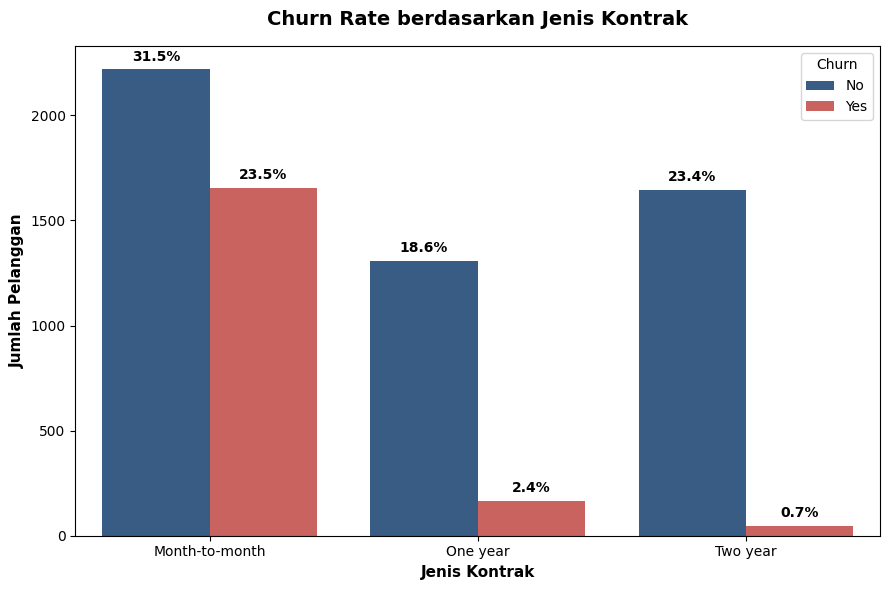

In [ ]:
total = len(df_telco)

plt.figure(figsize=(9, 6))

# Plot Countplot berdasarkan tipe Kontrak
ax = sns.countplot(
    data=df_telco,
    x='Contract',
    hue='Churn',
    palette=['#2b5c8f', '#d9534f']
)

# Judul dan Label
plt.title('Churn Rate berdasarkan Jenis Kontrak', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jenis Kontrak', fontsize=11, fontweight='bold')
plt.ylabel('Jumlah Pelanggan', fontsize=11, fontweight='bold')


# Menambahkan persentase di atas setiap batang grafik
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(100 * height / total):.1f}%'
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

***Insight*** : Pelanggan dengan kontrak Month-to-month memiliki churn yang jauh lebih tinggi dibandingkan pelanggan dengan kontrak satu tahun maupun dua tahun. Hal ini menunjukkan adanya perbedaan tingkat churn berdasarkan jenis kontrak

## Layanan Utama v. Churn Rate

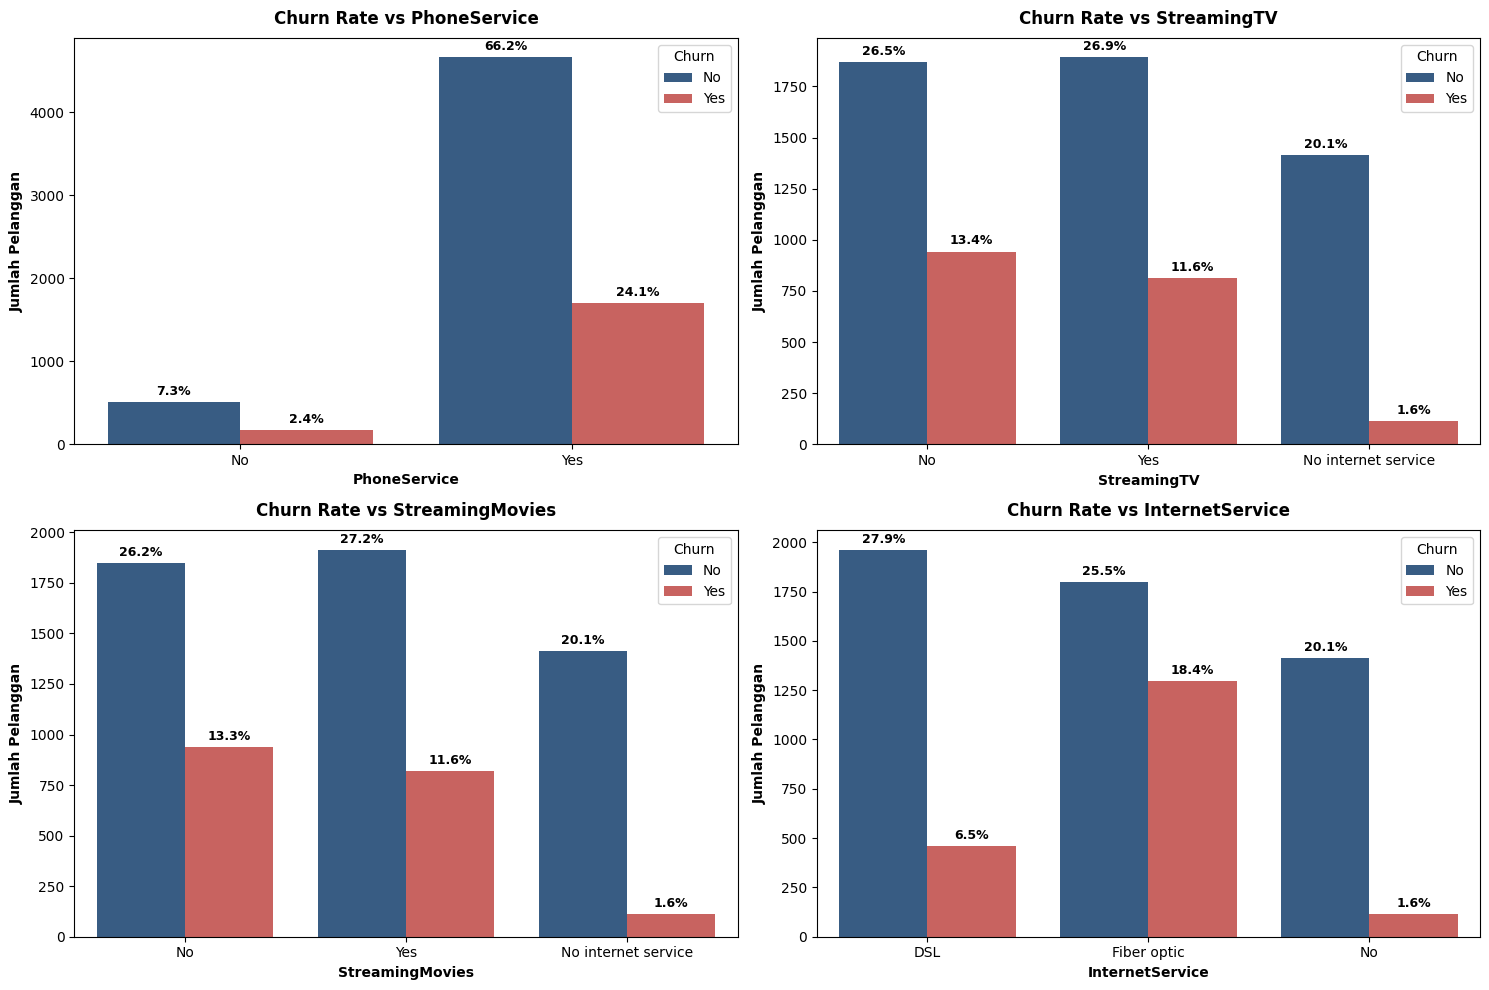

In [ ]:
# Daftar layanan yang dianalisis
cols = ['PhoneService', 'StreamingTV', 'StreamingMovies', 'InternetService']
total = len(df_telco)

# Membuat grid 2 baris, 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # Mengubah matriks 2x2 menjadi array 1D agar mudah di-loop

for i, col in enumerate(cols):
    # Plot Countplot per fitur
    sns.countplot(
        data=df_telco,
        x=col,
        hue='Churn',
        palette=['#2b5c8f', '#d9534f'],
        ax=axes[i]
    )

    # Judul dan Label
    axes[i].set_title(f'Churn Rate vs {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Jumlah Pelanggan', fontsize=10, fontweight='bold')

    # Menambahkan persentase di atas setiap batang
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{(100 * height / total):.1f}%'
            axes[i].annotate(
                percentage,
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                xytext=(0, 3),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold'
            )

plt.tight_layout()
plt.show()


***Insight*** : menunjukkan Faktor risiko churn paling krisis pada perusahaan berpusat pada pelanggan dengan kontrak bulanan (month-to-month) dan pengguna internet Fiber optic.

## C. Pengaruh Fitur Tambahan (Tech Support, Online Security, Online Back up, Device Protection) and Add On Bundling

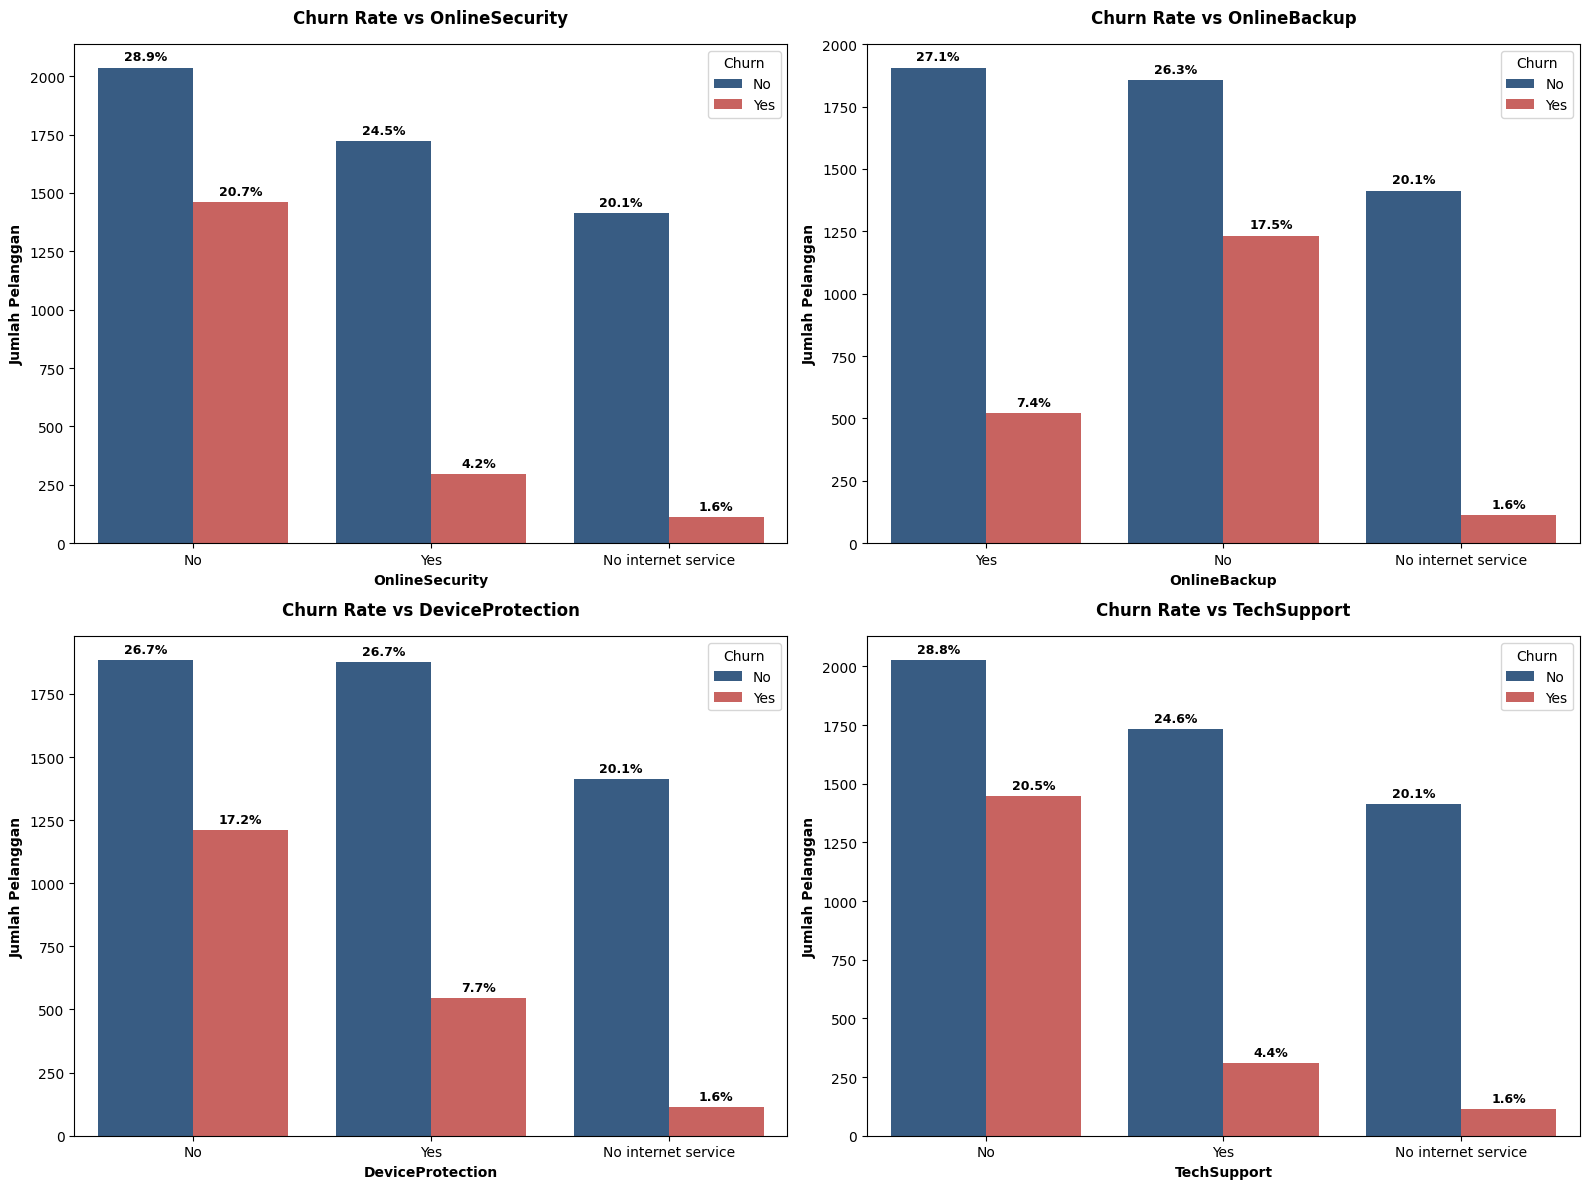

In [ ]:
# Daftar layanan yang dianalisis
features = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
total = len(df_telco)

# Membuat grid 2 baris, 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Mengubah matriks 2x2 menjadi array 1D agar mudah di-loop

for i, feature in enumerate(features):
    # Plot Countplot per fitur
    sns.countplot(
        data=df_telco,
        x=feature,
        hue='Churn',
        palette=['#2b5c8f', '#d9534f'],
        ax=axes[i]
    )

    # Judul dan Label
    axes[i].set_title(f'Churn Rate vs {feature}', fontsize=12, fontweight='bold', pad=15)
    axes[i].set_xlabel(feature, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Jumlah Pelanggan', fontsize=10, fontweight='bold')

    # Menambahkan persentase di atas setiap batang
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{(100 * height / total):.1f}%'
            axes[i].annotate(
                percentage,
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                xytext=(0, 3),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold'
            )

plt.tight_layout()
plt.show()

***Insight*** : Secara visual, pelanggan yang tidak menggunakan beberapa fitur tambahan seperti OnlineSecurity dan TechSupport terlihat memiliki jumlah churn yang lebih tinggi dibandingkan pelanggan yang menggunakan fitur tersebut

### EFEK PAKET BUNDLING KEAMANAN TERHADAP CHURN

**Efek "Paket Bundling Keamanan" Apakah Dapat Mempengaruhi Churn?**

In [ ]:
df_telco['No_Security_Support'] = (df_telco['OnlineSecurity'] == 'No') & (
      df_telco['TechSupport'] == 'No'
  )
print(
      pd.crosstab(
          df_telco['No_Security_Support'], df_telco['Churn'], normalize='index'
      ) * 100
  )

Churn                       No        Yes
No_Security_Support                      
False                86.213808  13.786192
True                 51.037995  48.962005


**SECURITY ADD ON BUNDLING ANALYSIS**

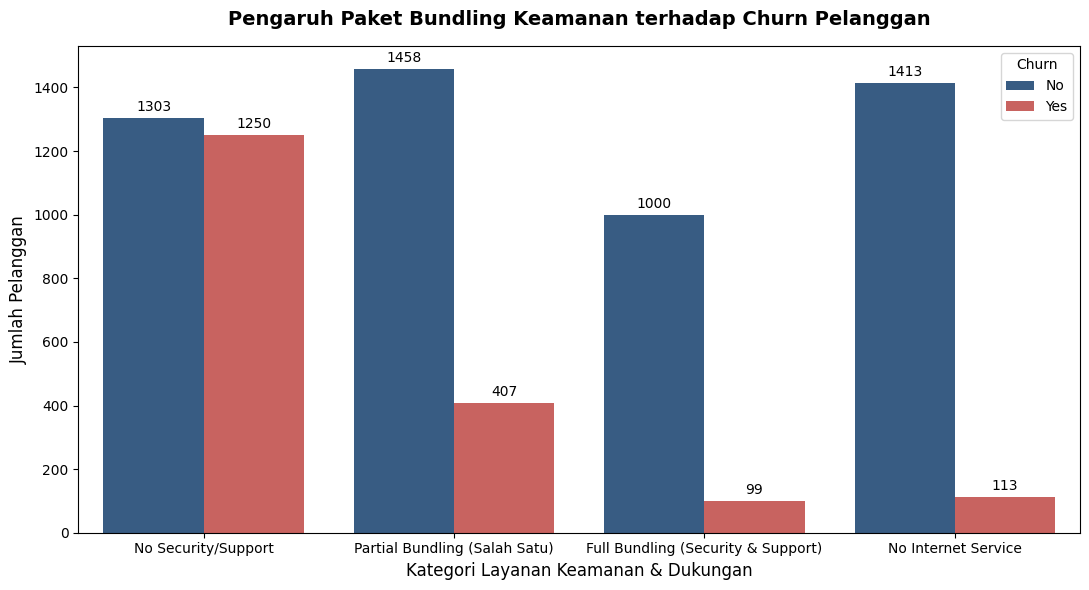

In [ ]:
# 1. Membuat fungsi untuk mengkategorikan paket bundling keamanan & dukungan teknis
def categorize_security(row):
    if row['OnlineSecurity'] == 'Yes' and row['TechSupport'] == 'Yes':
        return 'Full Bundling (Security & Support)'
    elif row['OnlineSecurity'] == 'Yes' or row['TechSupport'] == 'Yes':
        return 'Partial Bundling (Salah Satu)'
    elif row['OnlineSecurity'] == 'No internet service':
        return 'No Internet Service'
    else:
        return 'No Security/Support'

# Terapkan fungsi ke dataframe
df_telco['Kategori_Keamanan'] = df_telco.apply(categorize_security, axis=1)

# 2. Visualisasi Barplot Efek Bundling Keamanan terhadap Churn
plt.figure(figsize=(11, 6))
ax = sns.countplot(
    data=df_telco,
    x='Kategori_Keamanan',
    hue='Churn',
    palette=['#2b5c8f', '#d9534f']
)

plt.title('Pengaruh Paket Bundling Keamanan terhadap Churn Pelanggan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Layanan Keamanan & Dukungan', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.legend(title='Churn', loc='upper right')

# Menambahkan label teks angka di atas setiap batang grafik
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, color='black',
            xytext=(0, 3), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

Dari bar chart ini menghasilkan  point penting dari efek bundling keamanan ini :
- Dimana dengan ketiadaan fitur keamanan serta support (No Security/Support) menjadi pemicu utama pelanggan melakukan pemberhentian langganan, dengan jumlah churn churn (merah: 1.250 pelanggan) yang hampir setara dengan jumlah pelanggan yang bertahan (biru: 1.303 pelanggan),
- Pada partial bundling dengan memilih salah satu keamanan / support menunjukkan bahwa adanya penurunan jumlah pelanggan yang berhenti secara drastis dibandingkan tidak adanya fitur keamanan sama sekali
- Dengan adanya pemanfaatan Full bundling mencatatkan angka churn paling rendah sebesar 99 pelanggan yang berhenti, menunjukkan bahwa paket bundling keamanan efektif dalam meningkatkan kesetiaan pelanggan dalam layanan telco ini

## D. Pengaruh Kemudahan Cara Pembayaran terhadap Churn Rate

/tmp/ipykernel_464/2562714620.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)


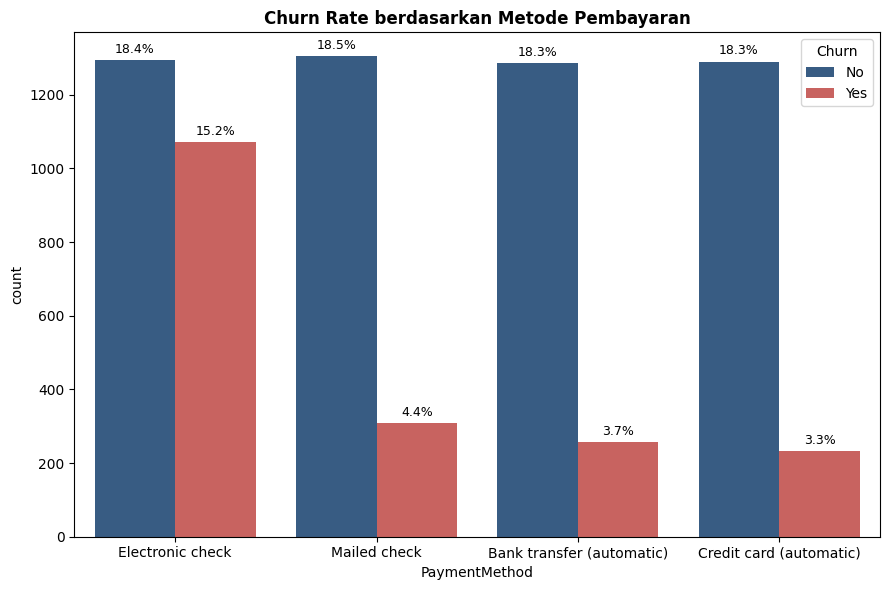

In [ ]:
plt.figure(figsize=(9, 6))
total = len(df_telco)

ax = sns.countplot(
    data=df_telco,
    x='PaymentMethod',
    hue='Churn',
    palette=['#2b5c8f', '#d9534f']
)

ax.set_title('Churn Rate berdasarkan Metode Pembayaran', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(100 * height / total):.1f}%'
        ax.annotate(percentage,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

***Insight*** : Terlihat adanya perbedaan jumlah churn antar metode pembayaran. Sehingga menjadi perbandingan antara metode pembayaran yang menggunakan sistem otomatis dan yang tidak. Temuan ini dapat menjadi dasar untuk melihat apakah kemudahan pembayaran berkaitan dengan churn.

## E. Analysis of Tenure, Monthly Charges, and Total Charges

In [ ]:
# Statistik numerik dipecah berdasarkan status Churn
df_clean.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T


Churn                          No          Yes
tenure         count  5174.000000  1869.000000
               mean     37.569965    17.979133
               std      24.113777    19.531123
               min       0.000000     1.000000
               25%      15.000000     2.000000
               50%      38.000000    10.000000
               75%      61.000000    29.000000
               max      72.000000    72.000000
MonthlyCharges count  5174.000000  1869.000000
               mean     61.265124    74.441332
               std      31.092648    24.666053
               min      18.250000    18.850000
               25%      25.100000    56.150000
               50%      64.425000    79.650000
               75%      88.400000    94.200000
               max     118.750000   118.350000
TotalCharges   count  5174.000000  1869.000000
               mean   2549.911442  1531.796094
               std    2329.954215  1890.822994
               min       0.000000    18.850000
               25%     572.900000   134.500000
               50%    1679.525000   703.550000
               75%    4262.850000  2331.300000
               max    8672.450000  8684.800000

**Kenapa pake median:**
Median digunakan karena lebih tahan terhadap nilai ekstrem dibandingkan rata-rata. Dengan adanya pelanggan dengan masa berlangganan atau total pembayaran yang sangat tinggi maupun rendah, median dapat memberikan gambaran nilai tengah yang lebih representatif untuk membandingkan kelompok churn dan non-churn

***Insight*** : Pada bagian tenure, nilai median pelanggan yang churn `(10 bulan)` menunjukkan jauh lebih rendah dibanding yang bertahan `(38 bulan)` dimana itu mengindikasikan risiko churn terkonsentrasi di pelanggan baru. Ini akan diuji signifikansinya di bawah.

/tmp/ipykernel_464/3939602710.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_telco, ax=axes[0], palette='Set2')
/tmp/ipykernel_464/3939602710.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_telco, ax=axes[1], palette='Set2')
/tmp/ipykernel_464/3939602710.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df_telco, ax=axes[2], palette='Set2')


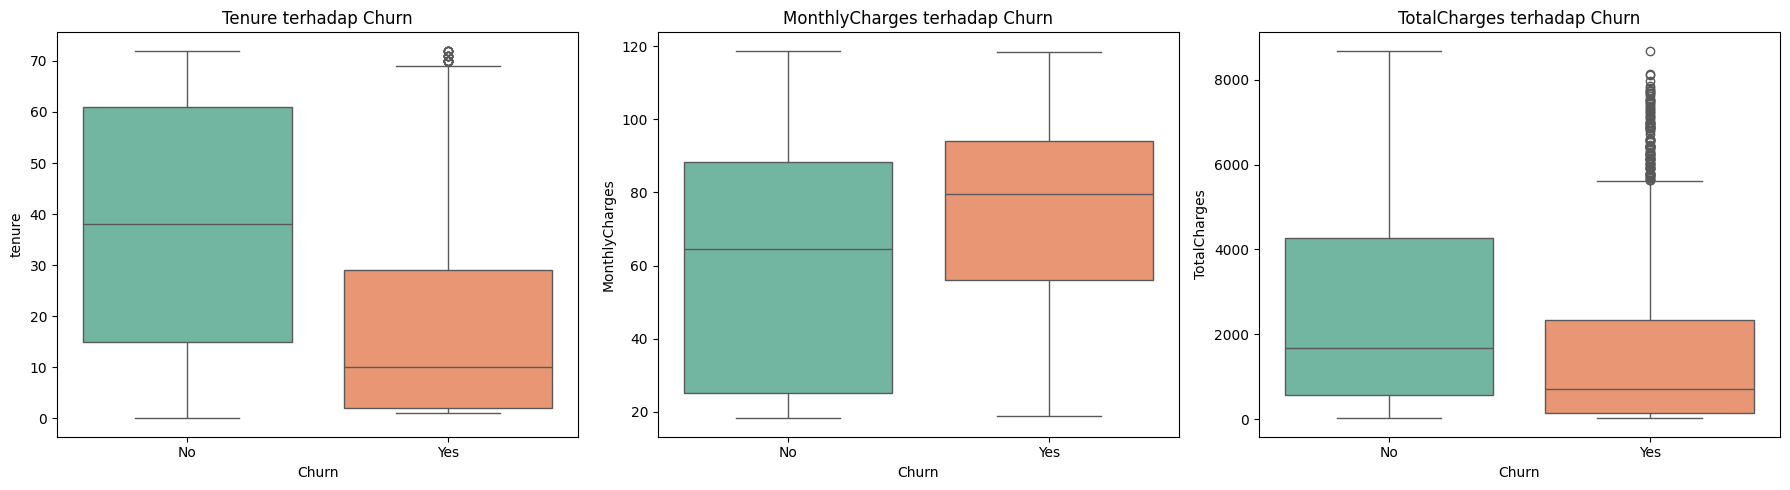

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set ukuran kanvas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df_telco, ax=axes[0], palette='Set2')
axes[0].set_title('Tenure terhadap Churn')

# 2. Monthly Charge vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_telco, ax=axes[1], palette='Set2')
axes[1].set_title('MonthlyCharges terhadap Churn')

# 3. Total Payment vs Churn
sns.boxplot(x='Churn', y='TotalCharges', data=df_telco, ax=axes[2], palette='Set2')
axes[2].set_title('TotalCharges terhadap Churn')

plt.tight_layout()
plt.show()



1. Tenure: median churn 10 bulan vs retained 38 bulan. Distribusi churn lebih terkonsentrasi pada tenure pendek.
2. MonthlyCharges: median churn `$79.65` vs retained `$64.43`. Kelompok churn cenderung memiliki tagihan bulanan lebih
tinggi
3. TotalCharges: median churn `$703.55` vs retained `$1679.53`. Perbedaan ini banyak dipengaruhi oleh lamanya tenure,
sehingga bukan sebagai penyebab churn.



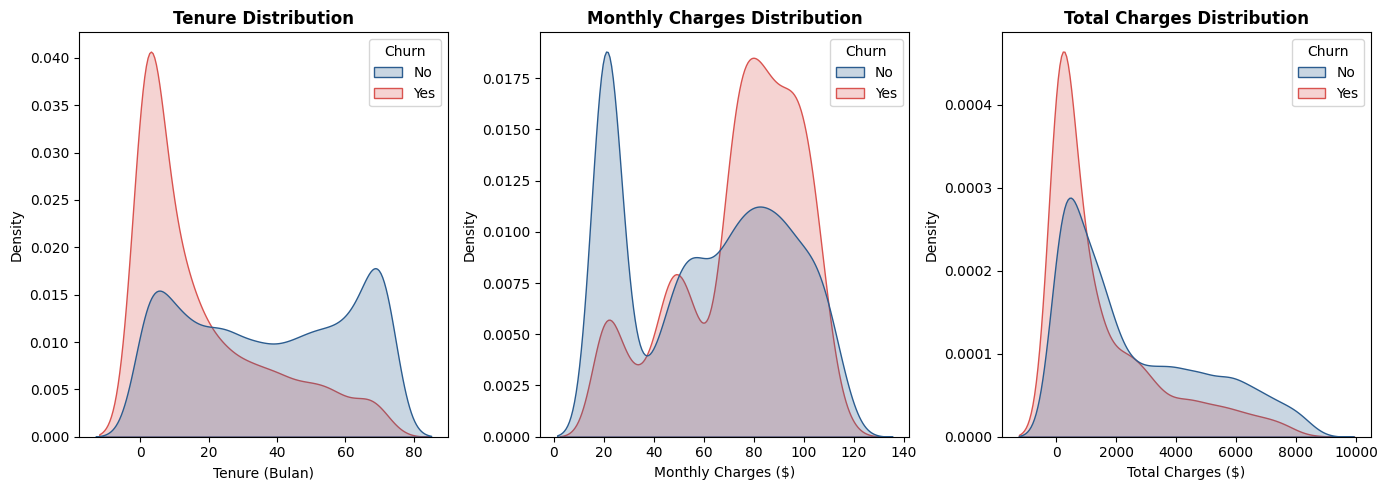

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Distribution of Tenure by Churn
sns.kdeplot(data=df_telco, x='tenure', hue='Churn', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True, ax=axes[0])
axes[0].set_title('Tenure Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Bulan)')

# Distribution of Monthly Charges by Churn
sns.kdeplot(data=df_telco, x='MonthlyCharges', hue='Churn', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')

# Distribution of Total Charges by Churn
sns.kdeplot(data=df_telco, x='TotalCharges', hue='Churn', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True, ax=axes[2])
axes[2].set_title('Total Charges Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.show()

***Insight*** : Menunjukkan risiko churn terbesar terpusat pada pelanggan di tahun pertama berlangganan (0–12 bulan) sebesar 14,7% dan pelanggan dengan tagihan bulanan tinggi (>$70/bulan) sebesar 18,0%, sehingga strategi retensi perusahaan harus difokuskan pada pemberian diskon/promo di awal masa langganan dan penyesuaian paket harga yang lebih kompetitif.

##  Heatmap (Korelasi Antar Variabel)

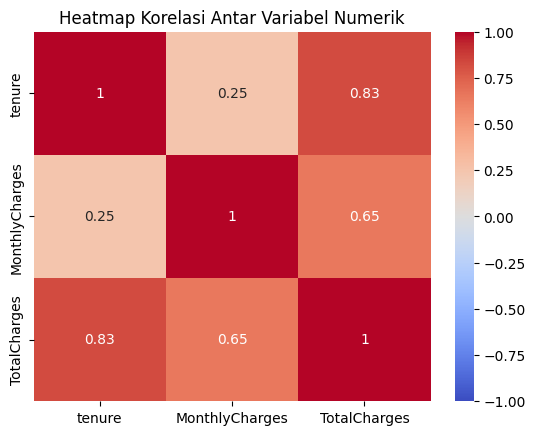

In [ ]:
plt.figure()
kolom_numerik = ['tenure', 'MonthlyCharges', 'TotalCharges']
korelasi = df_clean[kolom_numerik].corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()


***Insight*** : `TotalCharges` berkorelasi sangat tinggi dengan `tenure` (≈0.83), dan ini wajar secara matematis karena `TotalCharges` kurang lebih adalah hasil kali `tenure × MonthlyCharges`
yang artinya `TotalCharges` **bukan sinyal independen baru**, melainkan proxy dari tenure. Selain itu, hubungan tenure dengan MonthlyCharges relatif lemah. Temuan ini menunjukkan bahwa total pembayaran banyak dipengaruhi oleh lamanya pelanggan berlangganan

# 4. INFERENTIAL STATISTIC

### Uji Signifikansi


Tahap ini menguji **apakah pola itu signifikan secara statistik**, menggunakan:
- **Chi-square test + Cramer's V** untuk variabel kategorikal vs Churn (uji independensi + kekuatan asosiasi)
- **Mann-Whitney U test** untuk variabel numerik vs Churn (karena distribusinya tidak normal, dites non-parametrik)
- **T test - Independent Sample t-test** Membandingkan rata-rata dari dua kelompok yang berbeda/terpisah.

In [ ]:
from scipy import stats

## Chi Square Test

In [ ]:
def cramers_v(tabel_kontingensi):
    """Menghitung Cramer's V: ukuran kekuatan asosiasi antara 2 variabel kategorikal (0 = tidak ada, 1 = sangat kuat)"""
    chi2 = stats.chi2_contingency(tabel_kontingensi)[0]
    n = tabel_kontingensi.sum().sum()
    baris, kolom = tabel_kontingensi.shape
    return np.sqrt((chi2 / n) / min(kolom - 1, baris - 1))


kolom_kategorikal = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                      'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                      'Contract', 'PaperlessBilling', 'PaymentMethod']

hasil_uji = []
for kolom in kolom_kategorikal:
    tabel = pd.crosstab(df_clean[kolom], df_clean['Churn'])
    chi2, p_value, dof, expected = stats.chi2_contingency(tabel)
    v = cramers_v(tabel)
    hasil_uji.append({
        'variabel': kolom,
        'p_value': p_value,
        'cramers_v': round(v, 4),
        'signifikan (p<0.05)': p_value < 0.05
    })

tabel_hasil = pd.DataFrame(hasil_uji).sort_values('cramers_v', ascending=False).reset_index(drop=True)
tabel_hasil


,variabel,p_value,cramers_v,signifikan (p<0.05)
0,Contract,5.863038e-258,0.4101,True
1,OnlineSecurity,2.661150e-185,0.3474,True
2,TechSupport,1.443084e-180,0.3429,True
3,InternetService,9.571788e-160,0.3225,True
4,PaymentMethod,3.682355e-140,0.3034,True
5,OnlineBackup,2.079759e-131,0.2923,True
6,DeviceProtection,5.505219e-122,0.2816,True
7,StreamingMovies,2.667757e-82,0.2310,True
8,StreamingTV,5.528994e-82,0.2305,True
9,PaperlessBilling,4.073355e-58,0.1915,True


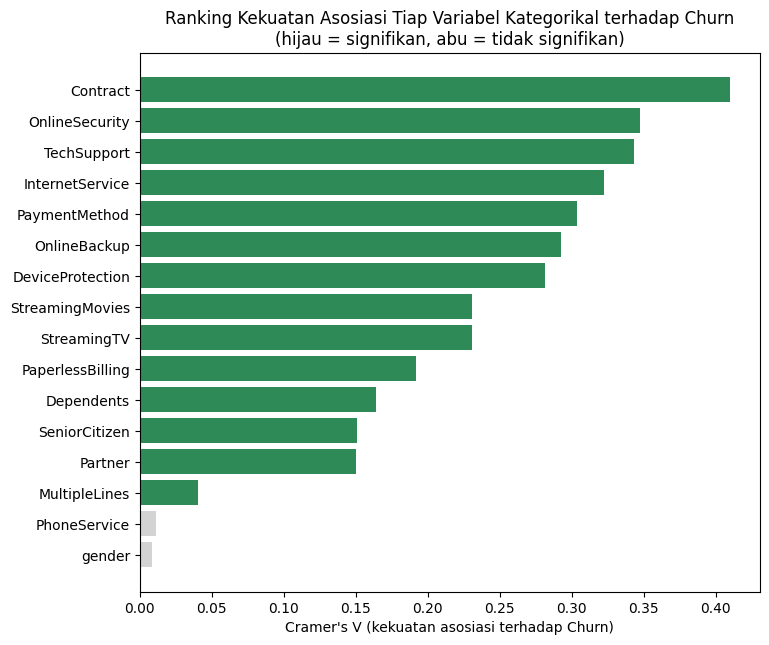

In [ ]:
# Visualisasi ranking kekuatan asosiasi
plt.figure(figsize=(8, 7))
warna_bar = ['seagreen' if s else 'lightgray' for s in tabel_hasil['signifikan (p<0.05)']]
plt.barh(tabel_hasil['variabel'], tabel_hasil['cramers_v'], color=warna_bar)
plt.gca().invert_yaxis()
plt.xlabel("Cramer's V (kekuatan asosiasi terhadap Churn)")
plt.title('Ranking Kekuatan Asosiasi Tiap Variabel Kategorikal terhadap Churn\n(hijau = signifikan, abu = tidak signifikan)')
plt.show()


**Temuan kunci:** `Contract` adalah variabel dengan asosiasi terkuat terhadap Churn, diikuti `OnlineSecurity`, `TechSupport`, dan `InternetService`. Sebaliknya, `gender` dan `PhoneService` **tidak signifikan**.

Melihat Pengaruh yang signifikan tiap Jenis Kontrak (Contract) terhadap Churn

Hipotesis:
- $H_0$: Jenis kontrak dan keputusan churn bersifat independen (tidak ada hubungan).
- $H_1$: Jenis kontrak dan keputusan churn memiliki hubungan yang signifikan.

In [ ]:
from scipy.stats import chi2_contingency

# Simulasi data контракт dan churn
np.random.seed(42)
n = 1000
contracts = np.random.choice(['Month-to-month', 'One year', 'Two year'], size=n, p=[0.55, 0.25, 0.20])
churns = []
for c in contracts:
    if c == 'Month-to-month':
        churns.append(np.random.choice(['Yes', 'No'], p=[0.427, 0.573]))
    elif c == 'One year':
        churns.append(np.random.choice(['Yes', 'No'], p=[0.15, 0.85]))
    else:
        churns.append(np.random.choice(['Yes', 'No'], p=[0.03, 0.97]))

df_contract = pd.DataFrame({'Contract': contracts, 'Churn': churns})

# Tabel Kontingensi & Uji Chi-Square
contingency_table = pd.crosstab(df_contract['Contract'], df_contract['Churn'])
chi2, p_val_chi2, dof, expected = chi2_contingency(contingency_table)


print("\n--- Hasil Uji Chi-Square (Contract) ---")
print(contingency_table)
print(f"Chi-Square  : {chi2:.4f}")
print(f"P-value     : {p_val_chi2:.4e}")


--- Hasil Uji Chi-Square (Contract) ---
Churn            No  Yes
Contract                
Month-to-month  329  230
One year        205   37
Two year        194    5
Chi-Square  : 133.4838
P-value     : 1.0336e-29


 ***$p$-value $< 0.05$*** membuktikan bahwa jenis kontrak bukan faktor kebetulan. Pelanggan dengan kontrak bulanan (Month-to-month) secara statistik terbukti memiliki risiko keluar yang paling tinggi karena tidak ada ikatan komitmen jangka panjang.

## UJI MANN-WHITNEY

***1. Menganalisis Early Life Churn***
(kecenderungan pelanggan baru untuk berhenti berlangganan di awal masa langganan)
Berdasarkan data analisis yang sudah dilakukan menunjukkan titik kritis **customer churn** paling tinggi terkonsentrasi pada tahun pertama (1–12 bulan pertama) dengan tingkat churn mencapai 47.7%.

Rumusan Hipotesis:
Dimana ingin membuktikan secara spesifik apakah pelanggan yang churn lebih cepat pergi (di masa awal / early life churn).

- $H_0$: Tidak ada perbedaan signifikan pada distribusi masa langganan (tenure) antara kelompok pelanggan yang churn dan yang bertahan berdasarkan tenure.
- $H_1$: Masa langganan (tenure) pelanggan yang churn lebih singkat (terkonsentrasi di awal) dibandingkan pelanggan yang bertahan.


**Kenapa menggunakan median dari data tenure?**


> Mayoritas churn terjadi di bulan-bulan awal (1–3 bulan pertama), tetapi banyak juga pelanggan setia yang bertahan hingga bertahun-tahun. Median, hanya melihat titik tengah dari semua data yang ada. Jadi, angka "Tenure" dari pelanggan yang churn tidak akan tercampur dengan data pelanggan yang retained.



In [ ]:
from scipy.stats import mannwhitneyu

# Uji Mann-Whitney U Test pada data asli
t_yes = df_telco[df_telco['Churn'] == 'Yes']['tenure']
t_no = df_telco[df_telco['Churn'] == 'No']['tenure']

u_stat, p_value = mannwhitneyu(t_yes, t_no, alternative='less')

print("--- Hasil Analisis Inferensial: Tenure & Early Life Churn ---")
print(f"Median Tenure (Churn = Yes) : {t_yes.median():.1f} bulan")
print(f"Median Tenure (Churn = No)  : {t_no.median():.1f} bulan")
print(f"Mann-Whitney U Statistic    : {u_stat:.4f}")
print(f"P-value                     : {p_value:.4e}")

--- Hasil Analisis Inferensial: Tenure & Early Life Churn ---
Median Tenure (Churn = Yes) : 10.0 bulan
Median Tenure (Churn = No)  : 38.0 bulan
Mann-Whitney U Statistic    : 2515538.0000
P-value                     : 1.2098e-208


***$p$-value < 0.05*** artinya perbedaan tenure langganan antara pelanggan yang churn dan yang setia itu signifikan, bukan sekadar kebetulan atau faktor hoki dalam pengambilan data. Jadi secara data kalau pelanggan yang churn memang punya kebiasaan melakukan pemberhentian langganan lebih cepat di awal masa langganan.

In [ ]:
# Uji variabel numerik (Mann-Whitney U test, karena distribusinya condong/tidak normal)
print("=== Uji Mann-Whitney U: variabel numerik vs Churn ===\n")
for kolom in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    grup_churn = df_clean.loc[df_clean['Churn'] == 'Yes', kolom]
    grup_tidak = df_clean.loc[df_clean['Churn'] == 'No', kolom]
    u_stat, p_value = stats.mannwhitneyu(grup_churn, grup_tidak, alternative='two-sided')
    print(f"{kolom:15s} | median churn={grup_churn.median():7.2f} | median bertahan={grup_tidak.median():7.2f} | p-value={p_value:.2e}")


=== Uji Mann-Whitney U: variabel numerik vs Churn ===

tenure          | median churn=  10.00 | median bertahan=  38.00 | p-value=2.42e-208
MonthlyCharges  | median churn=  79.65 | median bertahan=  64.43 | p-value=3.31e-54
TotalCharges    | median churn= 703.55 | median bertahan=1679.53 | p-value=5.69e-83


---

## T test - Independent Sample t-test

Pengaruh Biaya Bulanan (Monthly Charges) terhadap Churn

In [ ]:
from scipy.stats import ttest_ind

# Simulasi Data Monthly Charges
charges_churn = np.random.normal(loc=75.0, scale=15.0, size=int(n*0.3))
charges_retained = np.random.normal(loc=61.0, scale=18.0, size=int(n*0.7))

df_charges = pd.DataFrame({
    'MonthlyCharges': np.concatenate([charges_churn, charges_retained]),
    'Churn': ['Yes']*len(charges_churn) + ['No']*len(charges_retained)
})

# Uji Independent t-test
c_yes = df_charges[df_charges['Churn'] == 'Yes']['MonthlyCharges']
c_no = df_charges[df_charges['Churn'] == 'No']['MonthlyCharges']

t_stat, p_val_t = ttest_ind(c_yes, c_no, alternative='greater')

print("\n--- Hasil Uji Independent t-test (Monthly Charges) ---")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val_t:.4e}")
print(f"Rata-rata Churn    : ${c_yes.mean():.2f}")
print(f"Rata-rata Retained : ${c_no.mean():.2f}")


--- Hasil Uji Independent t-test (Monthly Charges) ---
T-statistic : 12.1788
P-value     : 3.2693e-32
Rata-rata Churn    : $75.30
Rata-rata Retained : $61.18




> ***$p$-value $< 0.05$*** secara statistik terbukti bahwa pelanggan yang churn membayar tagihan bulanan lebih tinggi (biasanya pengguna layanan fiber optic), yang mengindikasikan tingginya price sensitivity.



# 5. Summary

Hasil eksplorasi dan analisa kami bahwa data telco customer churn ini menunjukkan adanya problem dimana tingkat perpindahan pelanggan yang tinggi di industri telekomunikasi, yang berdampak langsung pada stabilitas pendapatan perusahaan. Stakeholder fokus pada tim ***Sales*** untuk mengoptimalkan pengelolaan pendapatan, jenis kontrak, dan penawaran produk. Setelah proses data understanding dan data cleaning, dari dataset sampel Telco Customer Churn, yang terdiri dari 7.043 baris dan 21 kolom, menunjukkan bahwa 73,5% pelanggan masih aktif (bertahan), sementara 26,5% sisanya memutuskan untuk berhenti berlangganan (churn). Hasil analisis, tingkat churn tertinggi terjadi pada tahun pertama langganan, terutama pada periode satu hingga dua belas bulan pertama, dengan tingkat churn mencapai 47,7%. Untuk mengatasi masalah ini, dirumuskan solusi dan rekomendasi strategi bisnis yang mencakup pelaksanaan program retensi dini bagi pelanggan baru di tahun pertama, dorongan peralihan dari kontrak bulanan ke kontrak tahunan melalui penawaran insentif, serta peningkatan kualitas dan nilai layanan melalui optimalisasi internet Fiber optic beserta fitur pendukung seperti Online Security dan Tech Support.

# Discover Insights from Telco Data



A. Kontrak & Masa Berlangganan (Tenure)
High-Risk Onboarding Period: Pelanggan dengan masa kerja 0–12 bulan memiliki churn rate tertinggi (47.44%). Churn rate turun drastis menjadi 9.51% pada pelanggan dengan tenure > 48 bulan.
Month-to-Month Contract: Pelanggan dengan kontrak bulanan mengalami churn rate sebesar 42.71%, jauh dibanding kontrak 1 tahun (11.27%) dan 2 tahun (2.83%).


B. Jenis Layanan & Fitur Proteksi (Bundling Effect)
Fiber Optic Issue: Pelanggan Fiber Optic mengalami churn rate sangat tinggi (41.89%), padahal membayar tarif bulanan paling mahal.
Impact of Protection & Support:
Tanpa Security/Support: Churn rate mencapai 48.96% (hampir separuh keluar).
Partial Bundling (Salah Satu): Churn rate turun ke 21.82%.
Full Bundling (OnlineSecurity + TechSupport): Churn rate sangat rendah, yaitu 9.01%.


# 6. Strategi & Rekomendasi

- **Fleksibelitas kontrak :** Pada layanan jaringan telco untuk customer yaitu dengan adanya kontrak month-to-month dimana tidak adanya penalti atau ketentuan pasti untuk berhenti sehingga customer mudah berpindah pindah ke kompetitor

- **Kualitas & Harga Fiber Optic :** Layanan fiber optic yang mahal belum tentu menghasilkan kepuasan customer yang optimal maupun biaya bulanan tinggi membuat customer rentan terhadap harga pada layanan

- **Otomasi pembayaran layanan :**  Orang yang menggunakan cek elektronik biasanya tidak menggunakan sistem auto-debit, jadi mereka harus membayar secara manual setiap bulan, yang meningkatkan gesekan psikologis (friction) untuk mempertahankan langganan.


*Strategic Recommendations*
1. **Retention & Onboarding Strategy (12 Bulan Pertama)**

- Welcome Incentive Program: Berikan insentif atau program loyalty points berkala pada bulan ke-3, ke-6, dan ke-12 untuk menahan pelanggan baru melewati masa kritis tahun pertama.
  - Milestone Bulan ke-3 (Fase Adaptasi & Edukasi) \
  Memastikan pelanggan tidak mengalami kendala teknis tersembunyi dan merasa puas dengan kecepatan internet awal.

  - Milestone Bulan ke-6 (Fase Evaluasi Paruh Pertama) \
  Menjaga engagement serta layanan agar pelanggan merasa diperhatikan dan tidak melirik penawaran dari kompetitor.

  - Milestone Bulan ke-12 (Fase Perpanjangan / Renewal Milestone)\
  Mencegah terjadinya natural churn saat masa langganan tahun pertama hampir habis.

- Contract Migration: Berikan diskon khusus (misal: potongan 10–15% untuk 3 bulan pertama) jika pelanggan Month-to-month mau berpindah ke kontrak 1 Year atau 2 Year. Mereka hanya perlu membayar sisa bulannya saja dan mereka punya 2 pilihan promo. Berikut contract migration lainnya :  
  - Penawaran Diskon Transisi (Migration Incentive) dimana mendapatkan gratis untuk di 1 bulan pertama
  - Added value bundling (Additional service OnlineSecurity/Techsupport/DeviceProtection)


2. **Payment Method Optimization & Auto-Pay Migration Strategy**

- Strategi ini mendorong pelanggan dari metode pembayaran manual, terutama electronic check, ke metode pembayaran otomatis seperti credit card atau auto-debit
  - Fase 1: One-Time Migration Incentive
  > Berikan insentif satu kali, seperti potongan tagihan atau cashback kecil pada bulan berikutnya bagi pelanggan yang beralih ke metode auto-pay
  
  - Fase 2: Edukasi & Kemudahan Akses
  > Berikan notifikasi melalui aplikasi, WhatsApp, atau email yang dilengkapi panduan sederhana agar pelanggan dapat mengubah metode pembayaran dengan mudah tanpa proses yang rumit

  - Fase 3: Evaluasi Dampak Bisnis
  > Insentif diberikan hanya satu kali sehingga biaya program dapat lebih terkontrol. Selain meningkatkan kemudahan pembayaran, penggunaan auto-pay diharapkan dapat mengurangi risiko pelanggan lupa membayar atau gagal melakukan pembayaran secara rutin

- Harapan: Mendorong pelanggan beralih ke metode pembayaran yang lebih praktis sekaligus mengurangi risiko churn dan kendala pembayaran


3. **Service Quality & Integrated Protection Bundling Strategy**

- Strategi ini menggabungkan peningkatan kualitas layanan Fiber Optic dengan penawaran OnlineSecurity dan TechSupport untuk meningkatkan value yang diterima pelanggan
  - Fase 1: Audit Teknis & Evaluasi Fiber Optic
  > Evaluasi pelanggan Fiber Optic yang churn untuk mengetahui kemungkinan masalah pada kualitas jaringan, harga, atau penanganan keluhan. Dengan rata-rata MonthlyCharges sekitar $74.44, kualitas layanan perlu sebanding dengan biaya yang dibayarkan pelanggan

  - Fase 2: Protection Bundle & Cross-Selling
  > Tawarkan paket Complete Security & Support kepada pelanggan Fiber Optic yang belum memiliki OnlineSecurity dan TechSupport. Untuk pelanggan baru, layanan tersebut dapat ditawarkan sebagai bagian dari paket tertentu atau melalui free
  
  - Fase 3: Evaluasi Biaya & Dampak
  > Sebelum memberikan diskon secara luas, perusahaan perlu membandingkan biaya bundling dengan potensi pendapatan yang dapat dipertahankan. Program dapat difokuskan terlebih dahulu pada pelanggan dengan risiko churn lebih tinggi dan dievaluasi berdasarkan perubahan churn setelah program berjalan

- Harapan: Meningkatkan perceived value pelanggan sekaligus mempertahankan pelanggan dengan biaya program yang tetap terkontrol


REFERENSI DATA/JURNAL/PORTO YANG DIPAKAI:
- https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- https://bisa.ai/portofolio/detail/NTM1MA
- https://kakazidane2000.medium.com/memprediksi-customer-churn-dengan-menggunakan-supervised-machine-learning-6b7b945d41a3
- https://journal.jci.co.id/jisbt/article/view/527/226